In [1]:
library(Seurat)
library(SeuratDisk)
library(SeuratData)
library(glue)
library(qs)
library(stringr)
library(reticulate)
library(ggsci)
library(ggplot2)
library(RColorBrewer)
library(SingleR)
library(Polychrome)
library(patchwork)
library(Matrix)
library(dplyr)
library(tidyr)

Warning message:
“package ‘Seurat’ was built under R version 4.4.3”
Loading required package: SeuratObject

Warning message:
“package ‘SeuratObject’ was built under R version 4.4.3”
Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Registered S3 method overwritten by 'SeuratDisk':
  method            from  
  as.sparse.H5Group Seurat

Warning message:
“package ‘qs’ was built under R version 4.4.2”
qs 0.26.3

Loading required package: SummarizedExperiment

Warning message:
“package ‘SummarizedExperiment’ was built under R version 4.4.2”
Loading required package: MatrixGenerics

Warning message:
“package ‘MatrixGenerics’ was built under R version 4.4.2”
Loading required package: matrixStats


Attaching package: ‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCum

In [2]:
options(future.globals.maxSize = 8e+09)
use_condaenv("ST_env", required = TRUE)

In [3]:
all_ra_samples <- list.dirs("/data/deyk/harry/spatial/RA_Xenium/data/post_qc_data_baysor/", recursive=FALSE, full.names=TRUE)
all_sample_ids <- str_extract(all_ra_samples, "RA\\d+[A-Z]*")
# Read in all QCed seurat objects
seurat_object_list <- lapply(all_ra_samples, function(dir){
    qread(glue("{dir}/QCed_seurat_obj.qs"))
})
names(seurat_object_list) <- all_sample_ids
# Select the data with the highest number of cells as the reference dataset for RPCA integration
reference_dataset <- which.max(sapply(seurat_object_list, function(obj){
    ncol(obj)
}))
reference_dataset <- names(seurat_object_list)[reference_dataset]
reference_dataset <- paste("data.", reference_dataset, sep="")
intersected_genes <- lapply(seurat_object_list, function(obj){
    rownames(obj)
})
intersected_genes <- Reduce(intersect, intersected_genes)
# Get all raw counts matrix 
all_count_matrices <- lapply(names(seurat_object_list), function(sample){
    counts <- seurat_object_list[[sample]][["Xenium"]]@layers$counts
    rownames(counts) <- rownames(seurat_object_list[[sample]])
    counts <- counts[intersected_genes, ]
    colnames(counts) <- paste(sample, colnames(seurat_object_list[[sample]]), sep="_")
    counts
})
all_count_matrices <- do.call(cbind, all_count_matrices)
sample_ids <- unlist(lapply(names(seurat_object_list), function(sample){
    rep(sample, ncol(seurat_object_list[[sample]]))
}))
combined_metadata <- data.frame(sample=sample_ids)
rownames(combined_metadata) <- colnames(all_count_matrices)

In [7]:
# Create a seurat object with the count matrix across all samples
object <- CreateSeuratObject(counts=all_count_matrices, meta.data=combined_metadata, assay="Xenium")
rm(seurat_object_list)

# Sketch integration

In [8]:
# Log-normalization
object <- NormalizeData(object, assay="Xenium", normalization.method="LogNormalize")
object[["Xenium"]] <- split(object[["Xenium"]], f=object$sample)
object <- FindVariableFeatures(object)

Normalizing layer: counts

Finding variable features for layer counts.RA331

Finding variable features for layer counts.RA362

Finding variable features for layer counts.RA401

Finding variable features for layer counts.RA442

Finding variable features for layer counts.RA443

Finding variable features for layer counts.RA457

Finding variable features for layer counts.RA480

Finding variable features for layer counts.RA489

Finding variable features for layer counts.RA494

Finding variable features for layer counts.RA519



In [9]:
# sample representative cells using leverage scores
object <- SketchData(object = object, ncells = 40000, method = "LeverageScore", sketched.assay = "sketch")

Calcuating Leverage Score

Attempting to cast layer counts.RA331 to dgCMatrix

Attempting to cast layer counts.RA362 to dgCMatrix

Attempting to cast layer counts.RA401 to dgCMatrix

Attempting to cast layer counts.RA442 to dgCMatrix

Attempting to cast layer counts.RA443 to dgCMatrix

Attempting to cast layer counts.RA457 to dgCMatrix

Attempting to cast layer counts.RA480 to dgCMatrix

Attempting to cast layer counts.RA489 to dgCMatrix

Attempting to cast layer counts.RA494 to dgCMatrix

Attempting to cast layer counts.RA519 to dgCMatrix

Attempting to cast layer data.RA331 to dgCMatrix

Attempting to cast layer data.RA362 to dgCMatrix

Attempting to cast layer data.RA401 to dgCMatrix

Attempting to cast layer data.RA442 to dgCMatrix

Attempting to cast layer data.RA443 to dgCMatrix

Attempting to cast layer data.RA457 to dgCMatrix

Attempting to cast layer data.RA480 to dgCMatrix

Attempting to cast layer data.RA489 to dgCMatrix

Attempting to cast layer data.RA494 to dgCMatrix

Att

In [11]:
DefaultAssay(object) <- "sketch"
object <- FindVariableFeatures(object)
object <- ScaleData(object)
object <- RunPCA(object, npcs=50)

Finding variable features for layer counts.RA331

Finding variable features for layer counts.RA362

Finding variable features for layer counts.RA401

Finding variable features for layer counts.RA442

Finding variable features for layer counts.RA443

Finding variable features for layer counts.RA457

Finding variable features for layer counts.RA480

Finding variable features for layer counts.RA489

Finding variable features for layer counts.RA494

Finding variable features for layer counts.RA519

Centering and scaling data matrix

PC_ 1 
Positive:  PTPRC, CXCR4, CYTIP, CD74, MS4A6A, CSF1R, HLA-DQA1, TRAC, CD163, IRF8 
	   CD2, CD3E, SPI1, MPEG1, IL7R, SLCO2B1, GPR183, CD14, CD4, CD3D 
	   CD68, HAVCR2, C1orf162, MS4A4A, CD28, CCL5, GLIPR1, CD27, MS4A1, ADAM28 
Negative:  AQP1, COL4A1, COL4A2, SPARC, CD34, VWF, COL6A1, CAV1, PDGFRB, CAVIN1 
	   COL15A1, ADGRL4, MMRN2, MCAM, TINAGL1, GNG11, SOX18, CLEC14A, THY1, COL1A1 
	   RGS5, LIFR, ECSCR, COL5A2, MYLK, RAMP2, FLT1, EMP1, EGFL7, CCL14 


[1] 13

[1] 13

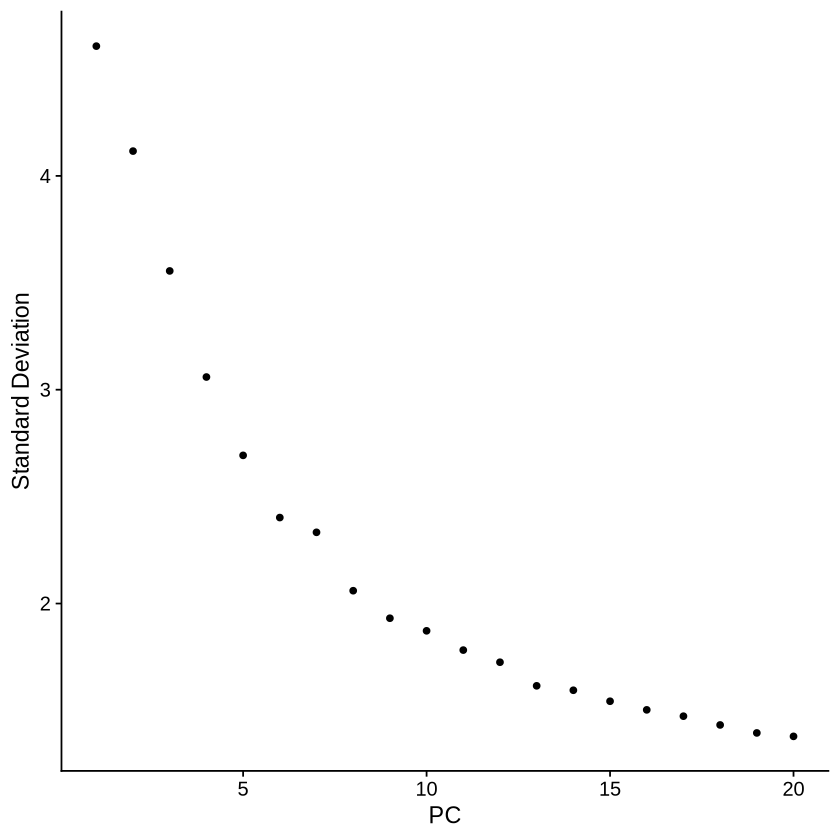

In [12]:
# Select number of PCs based on the Elbow plot and percent total variance explained
ElbowPlot(object)
pct <- object[["pca"]]@stdev / sum(object[["pca"]]@stdev) * 100

# Calculate cumulative percents for each PC
cumu <- cumsum(pct)

# Determine which PC exhibits cumulative percent greater than 90% and % variation associated with the PC as less than 5
co1 <- which(cumu > 90 & pct < 5)[1] # This finds the elbow
# Determine the difference between variation of PC and subsequent PC
co2 <- sort(which((pct[1:length(pct) - 1] - pct[2:length(pct)]) > 0.1), decreasing = T)[1] + 1

# last point where change of % of variation is more than 0.1%.
co2 # this determines the point where the standard deviation determined is still significantly more than the next
pcs <- min(co1, co2)

pcs

In [13]:
# Integration with Atoms
object <- IntegrateLayers(object, method = RPCAIntegration, orig = "pca", new.reduction = "integrated.rpca",
    dims = 1:pcs, k.anchor = 10, reference = which(Layers(object, search = "data") %in% c(reference_dataset)))

Computing within dataset neighborhoods

Finding anchors between all query and reference datasets

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 26288 anchors

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 47613 anchors

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 45864 anchors

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 38303 anchors

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 40227 anchors

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 48164 anchors

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 35714 anchors

Projecting new data onto SVD

Projecting new dat

In [14]:
object <- FindNeighbors(object, reduction = "integrated.rpca", dims = 1:30)
object <- FindClusters(object, resolution = 0.8)
object <- RunUMAP(object, reduction = "integrated.rpca", dims = 1:30, return.model = T)
object[["sketch"]] <- JoinLayers(object[["sketch"]])

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 400000
Number of edges: 11571610

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9818
Number of communities: 36
Elapsed time: 342 seconds


29 singletons identified. 7 final clusters.

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
UMAP will return its model

12:17:29 UMAP embedding parameters a = 0.9922 b = 1.112

12:17:29 Read 400000 rows and found 30 numeric columns

12:17:29 Using Annoy for neighbor search, n_neighbors = 30

12:17:29 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

12:18:33 Writing NN index file to temp file /scratch/lsftmp/9932328.tmpdir/RtmpqHwSeW/filefc169294628

12:18:33 Searching Annoy index using 1 thread, search_k = 3000

12:22:27 Annoy recall =

# SingleR label transfer for the atoms

In [15]:
lognorm_counts_sketch <- object[["sketch"]]@layers$data

In [17]:
amp_atlas <- qread("/data/deyk/harry/spatial/RA/data/scrna_seq_data/amp_preethi/processed_counts_seurat_obj.qs")
amp_atlas <- amp_atlas[, sample(colnames(amp_atlas), size=150000, replace=F)]
lognorm_counts_amp <- amp_atlas[["RNA"]]$data

In [24]:
rownames(lognorm_counts_sketch) <- rownames(object)
colnames(lognorm_counts_sketch) <- colnames(object[["sketch"]])

In [25]:
pred.grun.coarse <- SingleR(test=lognorm_counts_sketch, ref=lognorm_counts_amp, labels=amp_atlas@meta.data$cell_type_label, de.method="wilcox", num.threads=parallel::detectCores()-3, de.n=15)

In [47]:
data.frame(pred.grun.coarse) %>%
    select(labels) %>%
    AddMetaData(object, ., col.name="celltype.full") -> object
Idents(object) <- "celltype.full"

In [55]:
qsave(object, file="/data/deyk/harry/spatial/RA_Xenium/data/integration/sketch_integration_obj_Baysor.qs")

In [2]:
all_ra_samples <- list.dirs("/data1/deyk/harry/RA_Xenium/data/post_qc_data_baysor/", recursive=FALSE, full.names=TRUE)
all_sample_ids <- str_extract(all_ra_samples, "RA\\d+[A-Z]*")

# Project full dataset to the atoms' integrated space and also transfer major cell type labels

In [ ]:
projected_res <- object
projected_res[["sketch"]] <- split(projected_res[["sketch"]], f = projected_res$sample)
projected_res <- ProjectIntegration(object = projected_res, sketched.assay = "sketch", assay = "Xenium", reduction = "integrated.rpca")
projected_res <- ProjectData(object = projected_res, sketched.assay = "sketch", assay = "Xenium", sketched.reduction = "integrated.rpca.full",
    full.reduction = "integrated.rpca.full", dims = 1:30, refdata = list(celltype.projected = "celltype.full"))
projected_res <- RunUMAP(projected_res, reduction = "integrated.rpca.full", n.neighbors=15, dims = 1:15, reduction.name = "umap.full",
    reduction.key = "UMAP_full_", min.dist=0.01, spread=3)
projected_res[["Xenium"]] <- JoinLayers(projected_res[["Xenium"]])

# Perform subclustering within each broad cell type

In [ ]:
# Function to remove outlier clusters with less than 100 cells
discardOutlierClusters <- function(object){
    object@meta.data %>%
        group_by(subcluster_res) %>%
        summarize(count=n()) %>%
        filter(count > 100) %>%
        pull(subcluster_res) -> keep_cluster
    object <- subset(object, subset=subcluster_res %in% keep_cluster)
    object@meta.data$subcluster_res <- droplevels(object@meta.data$subcluster_res)
    Idents(object) <- "subcluster_res"
    return(object)
}

## B cells

In [ ]:
bcells <- subset(projected_res, idents="B-cells")
bcells <- FindNeighbors(obj,
                        return.neighbor=TRUE,
                        reduction="integrated.rpca.full",
                        dims=1:30)
bcells <- FindClusters(bcells,
                       resolution=0.1,
                       cluster.name="subcluster_res")
bcells <- discardOutlierClusters(bcells)
# Cluster 4 is a low-quality cluster and we remove it here
bcells <- subset(bcells, subset=subcluster_res != "4")

## Endothelial cells

In [ ]:
endothelial_cells <- subset(projected_res, idents="endothelial-cells")
endothelial_cells <- FindNeighbors(endothelial_cells,
                                   return.neighbor=TRUE,
                                   reduction="integrated.rpca.full",
                                   dims=1:30)
endothelial_cells <- FindClusters(endothelial_cells,
                                  resolution=0.15,
                                  cluster.name="subcluster_res")
endothelial_cells <- discardOutlierClusters(endothelial_cells)

## NK Cells

In [ ]:
# We were not able to resolve good subclusters in NK cells so no subclustering was performed
nkcells <- subset(projected_res, idents="NK-cells")

## T cells

In [ ]:
tcells <- subset(projected_res, idents="T-cells")
tcells <- FindNeighbors(tcells,
                        return.neighbor=TRUE,
                        reduction="integrated.rpca.full",
                        dims=1:30)
tcells <- FindClusters(tcells,
                       resolution=0.1,
                       cluster.name="subcluster_res")
tcells <- discardOutlierClusters(tcells)

# Fibroblasts, we do clustering on the atoms here due to the large full dataset size

In [ ]:
fibroblast_cells <- subset(projected_res, idents="fibroblast-cells")
fibroblast_cellls[["Xenium"]] <- split(fibroblast_cellls[["Xenium"]], f=fibroblast_cellls$sample)
fibroblast_cellls <- FindVariableFeatures(fibroblast_cellls)
fibroblast_cellls <- SketchData(fibroblast_cellls = fibroblast_cellls, ncells = 10000, method = "LeverageScore", sketched.assay = "sketch")
DefaultAssay(fibroblast_cellls) <- "sketch"
fibroblast_cellls <- FindVariableFeatures(fibroblast_cellls)
fibroblast_cellls <- ScaleData(fibroblast_cellls)
fibroblast_cellls <- RunPCA(fibroblast_cellls, npcs=50)
pct <- fibroblast_cellls[["pca"]]@stdev / sum(fibroblast_cellls[["pca"]]@stdev) * 100

# Calculate cumulative percents for each PC
cumu <- cumsum(pct)

# Determine which PC exhibits cumulative percent greater than 90% and % variation associated with the PC as less than 5
co1 <- which(cumu > 90 & pct < 5)[1] # This finds the elbow
# Determine the difference between variation of PC and subsequent PC
co2 <- sort(which((pct[1:length(pct) - 1] - pct[2:length(pct)]) > 0.1), decreasing = T)[1] + 1
pcs <- min(co1, co2)
fibroblast_cellls <- IntegrateLayers(fibroblast_cellls, method = RPCAIntegration, orig = "pca", new.reduction = "integrated.rpca",
    dims = 1:pcs, k.anchor = 10, reference = which(Layers(fibroblast_cellls, search = "data") %in% c(reference_dataset)))
fibroblast_cellls <- FindNeighbors(fibroblast_cellls, reduction = "integrated.rpca", dims = 1:30)
fibroblast_cellls <- FindClusters(fibroblast_cellls, resolution = 0.25)
table(fibroblast_cellls@meta.data$seurat_clusters)
fibroblast_cellls <- ProjectIntegration(fibroblast_cellls = fibroblast_cellls, sketched.assay = "sketch", assay = "Xenium", reduction = "integrated.rpca")
fibroblast_cellls <- ProjectData(fibroblast_cellls = fibroblast_cellls, sketched.assay = "sketch", assay = "Xenium", sketched.reduction = "integrated.rpca.full",
    full.reduction = "integrated.rpca.full", dims = 1:30, refdata = list(subcluster_res = "seurat_clusters"))
fibroblast_cellls@meta.data$subcluster_res <- as.factor(fibroblast_cellls@meta.data$subcluster_res)
fibroblast_cellls <- discardOutlierClusters(fibroblast_cellls)

# Myeloid, we do clustering on the atoms here due to the large full dataset size

In [ ]:
myeloid <- subset(projected_res, idents="myeloid")
myeloid[["Xenium"]] <- split(myeloid[["Xenium"]], f=myeloid$sample)
myeloid <- FindVariableFeatures(myeloid)
myeloid <- SketchData(myeloid = myeloid, ncells = 10000, method = "LeverageScore", sketched.assay = "sketch")
DefaultAssay(myeloid) <- "sketch"
myeloid <- FindVariableFeatures(myeloid)
myeloid <- ScaleData(myeloid)
myeloid <- RunPCA(myeloid, npcs=50)
pct <- myeloid[["pca"]]@stdev / sum(myeloid[["pca"]]@stdev) * 100

# Calculate cumulative percents for each PC
cumu <- cumsum(pct)

# Determine which PC exhibits cumulative percent greater than 90% and % variation associated with the PC as less than 5
co1 <- which(cumu > 90 & pct < 5)[1] # This finds the elbow
# Determine the difference between variation of PC and subsequent PC
co2 <- sort(which((pct[1:length(pct) - 1] - pct[2:length(pct)]) > 0.1), decreasing = T)[1] + 1
pcs <- min(co1, co2)
myeloid <- IntegrateLayers(myeloid, method = RPCAIntegration, orig = "pca", new.reduction = "integrated.rpca",
    dims = 1:pcs, k.anchor = 10, reference = which(Layers(myeloid, search = "data") %in% c(reference_dataset)))
myeloid <- FindNeighbors(myeloid, reduction = "integrated.rpca", dims = 1:30)
myeloid <- FindClusters(myeloid, resolution = 0.25)
table(myeloid@meta.data$seurat_clusters)
myeloid <- ProjectIntegration(myeloid = myeloid, sketched.assay = "sketch", assay = "Xenium", reduction = "integrated.rpca")
myeloid <- ProjectData(myeloid = myeloid, sketched.assay = "sketch", assay = "Xenium", sketched.reduction = "integrated.rpca.full",
    full.reduction = "integrated.rpca.full", dims = 1:30, refdata = list(subcluster_res = "seurat_clusters"))
myeloid@meta.data$subcluster_res <- as.factor(myeloid@meta.data$subcluster_res)
myeloid <- discardOutlierClusters(myeloid)

# After subclustering, merge objects together

In [ ]:
integrated_object_with_subclusters <- list("B-cells"=bcells,
                                          "endothelial-cells"=endothelial_cells,
                                          "fibroblast-cells"=fibroblast_cells,
                                          "myeloid"=myeloid,
                                          "NK-cells"=nkcells,
                                          "T-cells"=tcells)
integrated_object_with_subclusters <- lapply(integrated_object_with_subclusters, function(obj){
    DefaultAssay(obj) <- "Xenium"
})
# Append cell type prefix to subcluster IDs
cell_type_abbreviation <- c("B", "E", "F", "M", "NK", "T")
names(cell_type_abbreviation) <- names(integrated_object_with_subclusters)
integrated_object_with_subclusters <- lapply(names(integrated_object_with_subclusters), function(ct){
    renamed_ct <- cell_type_abbreviation[ct]
    obj <- integrated_object_with_subclusters[[ct]]
    obj@meta.data$subcluster_res <- as.factor(obj@meta.data$subcluster_res)
    Idents(obj) <- "subcluster_res"
    renamed_levels <- paste(renamed_ct, levels(Idents(obj)), sep="")
    levels(obj@meta.data$subcluster_res) <- renamed_levels
    Idents(obj) <- "subcluster_res"
    obj
})

# Add cell type annotations to individual seurat objects

In [ ]:
subcluster_all <- do.call(rbind, lapply(integrated_object_with_subclusters, function(obj){
    obj@meta.data %>% select(subcluster_res) -> metadat
}))
cell_names <- unlist(lapply(integrated_object_with_subclusters, function(obj){
    rownames(obj@meta.data)
}))
rownames(subcluster_all) <- cell_names
subcluster_all$subcluster_res <- as.factor(subcluster_all$subcluster_res)
ct_broad_abbreviation_mapping <- c("B-cells", "endothelial-cells", "fibroblast-cells", "myeloid", "NK-cells", "T-cells")
names(ct_broad_abbreviation_mapping) <- c("B", "E", "F", "M", "NK", "T")
subcluster_all$celltype_broad <- sapply(subcluster_all$subcluster_res, function(ct){sub("-.*", "", ct)})
subcluster_all$celltype_broad <- ct_broad_abbreviation_mapping[all_metadata_joined$celltype_broad]
subcluster_all <- split(subcluster_all, subcluster_all$sample)
subcluster_all <- lapply(subcluster_all, function(metadata){
    rownames(metadata) <- sub(".*RA\\d+[A-Z]*_", "", rownames(metadata))
    metadata
})
names(subcluster_all) <- unlist(lapply(subcluster_all, function(df){
    unique(df$sample)
}))

all_ra_samples <- list.dirs("/data/deyk/harry/spatial/RA_Xenium/data/post_qc_data_baysor/", recursive=FALSE, full.names=TRUE)
all_sample_ids <- str_extract(all_ra_samples, "RA\\d+[A-Z]*")
seurat_object_list <- lapply(all_ra_samples, function(dir){
    qread(glue("{dir}/QCed_seurat_obj.qs"))
})
names(seurat_object_list) <- all_sample_ids
seurat_object_list <- lapply(names(seurat_object_list), function(sample){
    seurat_obj <- seurat_object_list[[sample]]
    cluster_data <- subcluster_all[[sample]] %>%
        select(celltype_broad, subcluster_res)
    seurat_obj <- AddMetaData(seurat_obj, cluster_data, col.name=c("celltype_broad", "celltype_subcluster"))
    qsave(seurat_obj, glue("/data1/deyk/harry/RA_Xenium/data//post_qc_data_baysor/{sample}/final_version_seurat_obj.qs"))
})